# ✋✂️🧻 ResNet Transfer Learning with Rock-Paper-Scissors Dataset

This notebook demonstrates transfer learning using ResNet50V2 on the Rock-Paper-Sc

***1. 📦 Step 1: Install and Import Required Libraries***

### Resolving Protobuf and `tensorflow-datasets` Compatibility Issues

The previous errors indicate a conflict in `protobuf` versions that prevents `tensorflow-datasets` from loading correctly. To resolve this, we will perform a clean reinstallation of `tensorflow` and `tensorflow-datasets`.

**Steps to follow:**
1. Run the following two code cells to uninstall and reinstall the libraries.
2. **Important:** After these cells execute, go to **Runtime > Restart runtime...** from the Colab menu.
3. After the runtime restarts, re-run your notebook from the beginning, starting with the 'Install and Import Required Libraries' cell (`wiFBfnCsz5hd`).

In [1]:
# Uninstall conflicting versions of tensorflow, tensorflow-datasets, and protobuf
!pip uninstall -y tensorflow tensorflow-datasets protobuf


Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6


In [2]:
# Reinstall tensorflow. This will automatically pull in compatible versions of tensorflow-datasets and protobuf.
!pip install -q tensorflow
!pip install -q tensorflow-datasets

print("Libraries uninstalled and reinstalled. Please RESTART THE RUNTIME (Runtime > Restart runtime...) and then re-run your notebook from the beginning.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 28.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is i

***1. 📦 Step 1: Install and Import Required Libraries***

In [1]:
# 📦 Step 1: Install and Import Required Libraries

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

***2. 🗂 Step 2: Load the Dataset***

In [3]:
!pip install importlib_resources

# 🗂 Step 2: Load the Dataset
(ds_train,ds_test),ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train','test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.LZ2VHO_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.LZ2VHO_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author 

***3.  🧹 Step 3: Normalize and Batch the Data***

In [4]:
# 🧹 Step 3: Normalize and Batch the Data
def normalize_img(img,lbl):
  return tf.cast(img,tf.float32) / 255.0, lbl

batch_size= 64

ds_train = ds_train.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.map(normalize_img,num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

***4. 🧠 Step 4: Define the Transfer Learning Model***

In [5]:
# 🧠 Step 4: Define the Transfer Learning Model
base_model = tf.keras.applications.ResNet50V2(
    input_shape = (300,300,3),
    include_top=False,
    weights = 'imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Resizing(300,300),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(3,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 10, 10, 2048)   │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

***🚀 Step 5: Train the Model***

In [7]:
# 🚀 Step 5: Train the Model
hist = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=5
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9119 - loss: 0.4737 - val_accuracy: 0.7554 - val_loss: 0.5156
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 0.9917 - loss: 0.1475 - val_accuracy: 0.7769 - val_loss: 0.4760
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 289ms/step - accuracy: 0.9972 - loss: 0.0856 - val_accuracy: 0.7769 - val_loss: 0.4632
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step - accuracy: 1.0000 - loss: 0.0594 - val_accuracy: 0.7796 - val_loss: 0.4606
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 1.0000 - loss: 0.0441 - val_accuracy: 0.7796 - val_loss: 0.4575


***📈 Step 6: Visualize Training Results***

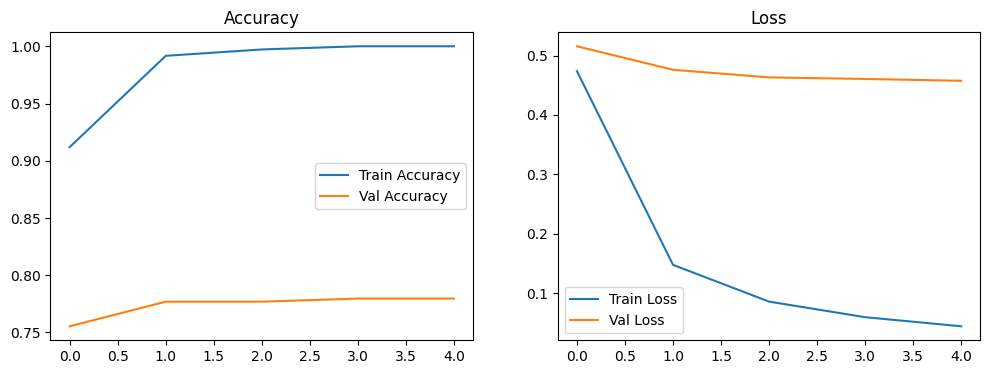

In [8]:
# 📈 Step 6: Visualize Training Results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

***🧪 Step 7: Evaluate on Test Set***

In [9]:
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test Accuracy: {test_acc:.4f} Test Loss {test_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.7796 - loss: 0.4575
Test Accuracy: 0.7796 Test Loss 0.4574604332447052


***🔍 Step 8: Inference on a Random Test Image***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


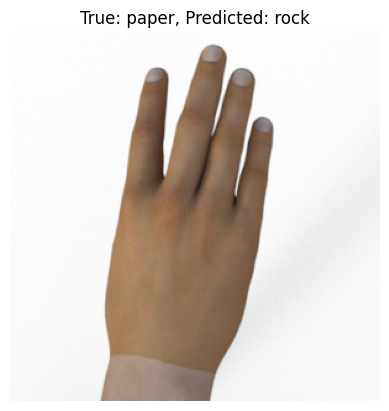

In [12]:
# 🔍 Step 8: Inference on a Random Test Image
import random
import tensorflow_datasets as tfds

# Load test data again without batching
raw_test_ds = tfds.load('rock_paper_scissors',split='test',as_supervised=True)

# Pick a random test sample
sample_list = list(raw_test_ds)
sample_img,sample_lbl = random.choice(sample_list)

# preprocess image
input_img = tf.image.resize(sample_img,(300,300))
input_img = tf.expand_dims(input_img,axis=0)

# Predict
pred = model.predict(input_img)
pred_class = tf.argmax(pred[0])

# Class labels
class_names = ds_info.features['label'].names

# Display
plt.imshow(sample_img)
plt.title(f"True: {class_names[sample_lbl]}, Predicted: {class_names[pred_class]}")
plt.axis('off')
plt.show()